In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow.keras import models, layers 

In [2]:
img_size = 256
batch_size = 32

In [3]:
data = tf.keras.preprocessing.image_dataset_from_directory("diseases",
                                                           shuffle=True,
                                                           image_size=(img_size,img_size),
                                                           batch_size=batch_size)

Found 1228 files belonging to 2 classes.


In [4]:
classes = data.class_names
classes

['Acne and Rosacea Photos', 'Bullous Disease Photos']

In [5]:
len(data)

39

In [6]:
import numpy as np
for label, img in data.take(1):
    print(img.numpy)

<bound method _EagerTensorBase.numpy of <tf.Tensor: shape=(32,), dtype=int32, numpy=
array([1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 0, 0], dtype=int32)>>


In [7]:
import matplotlib.pyplot as plt 

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

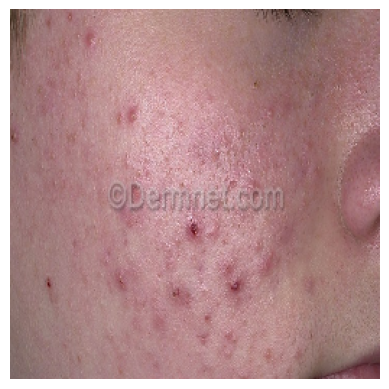

In [21]:
plt.imshow(label[21].numpy().astype("uint8"))
plt.axis("off")

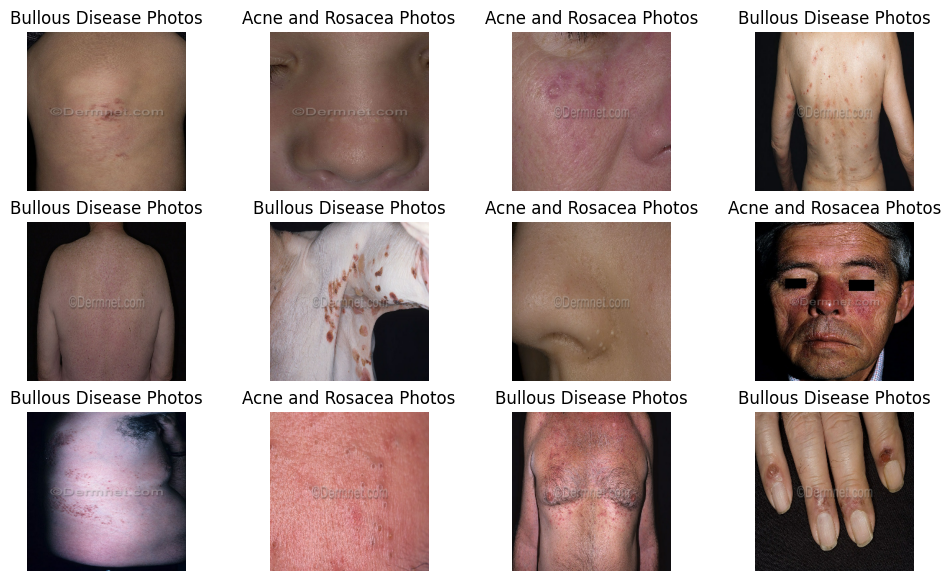

In [36]:
plt.figure(figsize=(12,7))

for label, image in data.take(1):
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(label[i].numpy().astype("uint8"))
        plt.title(classes[image[i]])
        plt.axis("off")


In [37]:
train_data = 0.8

len(data)*train_data

31.200000000000003

In [38]:
train_data = data.take(31)
test_data = data.skip(31)

In [39]:
len(train_data)

31

In [40]:
len(test_data)

8

In [41]:
val_data = test_data.take(1)

In [42]:
len(val_data)

1

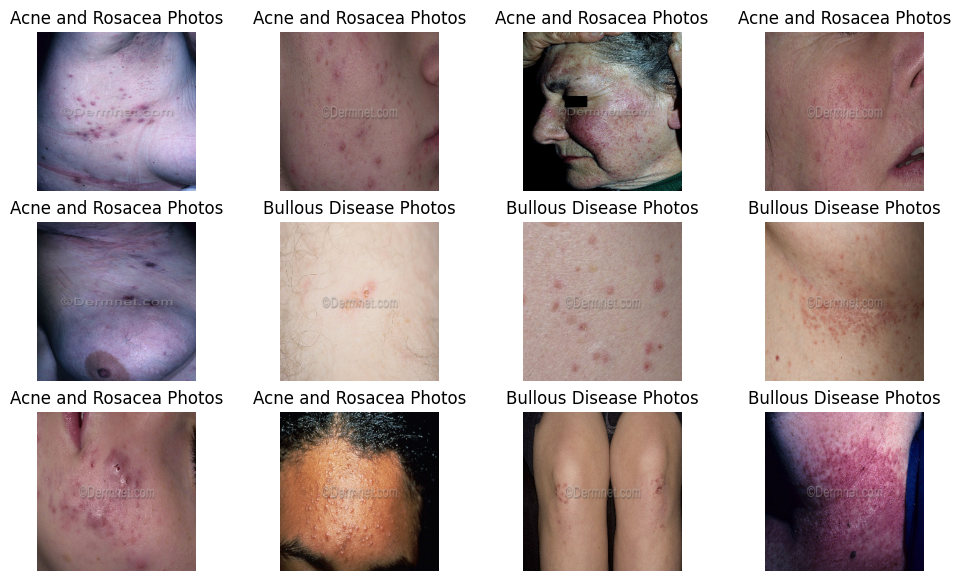

In [46]:
plt.figure(figsize=(12,7))
for label, image in val_data:
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.imshow(label[i].numpy().astype("uint8"))
        plt.title(classes[image[i]])
        plt.axis("off")

In [47]:
def get_data_partition_tf(data, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=1200):
    
    ds_size = data.cardinality().numpy()
    
    if shuffle:
        data = data.shuffle(shuffle_size, seed=12)
    
    train_size = int(ds_size * train_split)
    val_size = int(ds_size * val_split)
    
    train_ds = data.take(train_size)
    val_ds = data.skip(train_size).take(val_size)
    test_ds = data.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [48]:
train_ds, test_ds, val_ds = get_data_partition_tf(data)

In [66]:
len(test_data)

8

In [67]:
list1 = [train_ds, val_ds, test_ds]

for i in range(len(list1)):
    list1[i] = list1[i].cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

train_ds, val_ds, test_ds = list1

In [70]:
resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(img_size, img_size),
    layers.Rescaling(1.0/255)
])

In [71]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2)
])

In [ ]:
channels = 3 # RGB channels means colors 
input_shape = (batch_size,img_size, img_size, channels)
n_classes = 2
model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,(3,3), activation='relu', input_shape = input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes,activation='softmax')
])
model.build(input_shape=input_shape)
